# FitBit Fitness Tracker - Calorie Burn Prediction

---

## 1. Problem Statement

### 1.1 Business Context

Wearable fitness devices such as FitBit collect a wide range of daily activity data from users, including step counts, distances covered at various activity intensities, and minutes spent in different activity levels. One of the most valuable metrics for users and health professionals is the number of calories burnt during a day, as it directly informs weight management, diet planning, and overall fitness tracking.

However, calorie estimation in commercial devices often relies on simplified formulas that may not capture the complex, non-linear relationships between various activity indicators. Building an accurate machine learning model to predict calorie expenditure from these activity indicators can improve the reliability of fitness recommendations and provide more actionable health insights.

### 1.2 Objective

The objective of this project is to build a regression model that predicts the number of calories burnt by a user based on a set of daily activity indicators captured by FitBit devices. The approach includes:

- Performing thorough Exploratory Data Analysis (EDA) to understand the data distribution, relationships, and quality.
- Preprocessing the data by handling missing values, removing redundant features, and scaling.
- Applying a clustering-based approach (KMeans) to segment users/activity patterns before model training.
- Training and comparing multiple regression models (Decision Tree Regressor and XGBoost Regressor) with hyperparameter tuning via GridSearchCV.
- Selecting the best model for each cluster based on the R-squared score.

### 1.3 Dataset Description

The dataset contains daily activity records from FitBit users with the following 15 columns:

| Column | Description |
|---|---|
| Id | User identifier |
| ActivityDate | Date of the recorded activity |
| TotalSteps | Total steps taken on that day |
| TotalDistance | Total distance covered |
| TrackerDistance | Distance as recorded by the tracker |
| LoggedActivitiesDistance | Distance from manually logged activities |
| VeryActiveDistance | Distance covered during high-intensity activity |
| ModeratelyActiveDistance | Distance covered during moderate-intensity activity |
| LightActiveDistance | Distance covered during low-intensity activity |
| SedentaryActiveDistance | Distance during sedentary periods |
| VeryActiveMinutes | Minutes spent in high-intensity activity |
| FairlyActiveMinutes | Minutes spent in moderate-intensity activity |
| LightlyActiveMinutes | Minutes spent in low-intensity activity |
| SedentaryMinutes | Minutes spent in sedentary state |
| Calories (Target) | Total calories burnt |

### 1.4 Approach

The project follows a structured machine learning pipeline:

1. Data Loading and Initial Inspection
2. Exploratory Data Analysis (EDA)
3. Data Preprocessing (cleaning, imputation, feature engineering)
4. KMeans Clustering to segment the data
5. Model Training with hyperparameter tuning per cluster
6. Model Evaluation and Selection


---
## 2. Import Libraries


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.impute import KNNImputer
from sklearn.cluster import KMeans
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from xgboost import XGBRegressor
from kneed import KneeLocator

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

print("All libraries imported successfully.")


All libraries imported successfully.


---
## 3. Data Loading and Initial Inspection


In [2]:
# Load the dataset
df = pd.read_csv("FitBit data.csv")
print("Dataset loaded successfully.")
print("Shape of the dataset:", df.shape)


Dataset loaded successfully.
Shape of the dataset: (457, 15)


In [3]:
# Display the first 10 rows
df.head(10)


,Id,ActivityDate,TotalSteps,TotalDistance,TrackerDistance,LoggedActivitiesDistance,VeryActiveDistance,ModeratelyActiveDistance,LightActiveDistance,SedentaryActiveDistance,VeryActiveMinutes,FairlyActiveMinutes,LightlyActiveMinutes,SedentaryMinutes,Calories
0,1503960366,3/25/2016,11004,7.11,7.11,0.0,2.57,0.46,4.07,0.0,33,12,205,804,1819
1,1503960366,3/26/2016,17609,11.55,11.55,0.0,6.92,0.73,3.91,0.0,89,17,274,588,2154
2,1503960366,3/27/2016,12736,8.53,8.53,0.0,4.66,0.16,3.71,0.0,56,5,268,605,1944
3,1503960366,3/28/2016,13231,8.93,8.93,0.0,3.19,0.79,4.95,0.0,39,20,224,1080,1932
4,1503960366,3/29/2016,12041,7.85,7.85,0.0,2.16,1.09,4.61,0.0,28,28,243,763,1886
5,1503960366,3/30/2016,10970,7.16,7.16,0.0,2.36,0.51,4.29,0.0,30,13,223,1174,1820
6,1503960366,3/31/2016,12256,7.86,7.86,0.0,2.29,0.49,5.04,0.0,33,12,239,820,1889
7,1503960366,4/1/2016,12262,7.87,7.87,0.0,3.32,0.83,3.64,0.0,47,21,200,866,1868
8,1503960366,4/2/2016,11248,7.25,7.25,0.0,3.00,0.45,3.74,0.0,40,11,244,636,1843
9,1503960366,4/3/2016,10016,6.37,6.37,0.0,0.91,1.28,4.18,0.0,15,30,314,655,1850


In [4]:
# Display the last 5 rows
df.tail()


,Id,ActivityDate,TotalSteps,TotalDistance,TrackerDistance,LoggedActivitiesDistance,VeryActiveDistance,ModeratelyActiveDistance,LightActiveDistance,SedentaryActiveDistance,VeryActiveMinutes,FairlyActiveMinutes,LightlyActiveMinutes,SedentaryMinutes,Calories
452,8877689391,4/8/2016,23014,20.389999,20.389999,0.0,11.10,0.63,8.62,0.00,70,29,359,982,4196
453,8877689391,4/9/2016,16470,8.070000,8.070000,0.0,0.00,0.02,8.02,0.00,90,9,289,1052,3841
454,8877689391,4/10/2016,28497,27.530001,27.530001,0.0,21.92,1.12,4.46,0.00,128,46,211,1055,4526
455,8877689391,4/11/2016,10622,8.060000,8.060000,0.0,1.47,0.15,6.37,0.01,18,7,225,1190,2820
456,8877689391,4/12/2016,2350,1.780000,1.780000,0.0,0.00,0.00,1.78,0.00,0,0,58,531,938


In [5]:
# Check data types and non-null counts
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 457 entries, 0 to 456
Data columns (total 15 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Id                        457 non-null    int64  
 1   ActivityDate              457 non-null    str    
 2   TotalSteps                457 non-null    int64  
 3   TotalDistance             457 non-null    float64
 4   TrackerDistance           457 non-null    float64
 5   LoggedActivitiesDistance  457 non-null    float64
 6   VeryActiveDistance        457 non-null    float64
 7   ModeratelyActiveDistance  457 non-null    float64
 8   LightActiveDistance       457 non-null    float64
 9   SedentaryActiveDistance   457 non-null    float64
 10  VeryActiveMinutes         457 non-null    int64  
 11  FairlyActiveMinutes       457 non-null    int64  
 12  LightlyActiveMinutes      457 non-null    int64  
 13  SedentaryMinutes          457 non-null    int64  
 14  Calories             

In [6]:
# Statistical summary of numerical columns
df.describe()


,Id,TotalSteps,TotalDistance,TrackerDistance,LoggedActivitiesDistance,VeryActiveDistance,ModeratelyActiveDistance,LightActiveDistance,SedentaryActiveDistance,VeryActiveMinutes,FairlyActiveMinutes,LightlyActiveMinutes,SedentaryMinutes,Calories
count,4.570000e+02,457.000000,457.000000,457.000000,457.000000,457.000000,457.000000,457.000000,457.000000,457.000000,457.000000,457.000000,457.000000,457.000000
mean,4.628595e+09,6546.562363,4.663523,4.609847,0.179427,1.180897,0.478643,2.890197,0.001904,16.623632,13.070022,170.070022,995.282276,2189.452954
std,2.293781e+09,5398.493064,4.082072,4.068540,0.849232,2.487159,0.830995,2.237523,0.008487,28.919704,36.208635,122.205372,337.021404,815.484523
min,1.503960e+09,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,32.000000,0.000000
25%,2.347168e+09,1988.000000,1.410000,1.280000,0.000000,0.000000,0.000000,0.870000,0.000000,0.000000,0.000000,64.000000,728.000000,1776.000000
50%,4.057193e+09,5986.000000,4.090000,4.090000,0.000000,0.000000,0.020000,2.930000,0.000000,0.000000,1.000000,181.000000,1057.000000,2062.000000
75%,6.391747e+09,10198.000000,7.160000,7.110000,0.000000,1.310000,0.670000,4.460000,0.000000,25.000000,16.000000,257.000000,1285.000000,2667.000000
max,8.877689e+09,28497.000000,27.530001,27.530001,6.727057,21.920000,6.400000,12.510000,0.100000,202.000000,660.000000,720.000000,1440.000000,4562.000000


In [7]:
# Check for duplicate rows
duplicate_count = df.duplicated().sum()
print("Number of duplicate rows:", duplicate_count)


Number of duplicate rows: 0


In [8]:
# Check unique user IDs
print("Number of unique users:", df['Id'].nunique())
print("Unique User IDs:", df['Id'].unique())


Number of unique users: 35
Unique User IDs: [1503960366 1624580081 1644430081 1844505072 1927972279 2022484408
 2026352035 2320127002 2347167796 2873212765 2891001357 3372868164
 3977333714 4020332650 4057192912 4319703577 4388161847 4445114986
 4558609924 4702921684 5553957443 5577150313 6117666160 6290855005
 6391747486 6775888955 6962181067 7007744171 7086361926 8053475328
 8253242879 8378563200 8583815059 8792009665 8877689391]


---
## 4. Exploratory Data Analysis (EDA)

This section explores the dataset to understand the distribution of features, relationships between variables, and identify any data quality issues.


### 4.1 Missing Value Analysis


In [9]:
# Check for missing values in each column
missing_values = df.isnull().sum()
missing_percent = (df.isnull().sum() / len(df)) * 100
missing_df = pd.DataFrame({
    'Missing Count': missing_values,
    'Missing Percentage': missing_percent
})
print(missing_df)
print()
print("Total missing values in dataset:", df.isnull().sum().sum())


                          Missing Count  Missing Percentage
Id                                    0                 0.0
ActivityDate                          0                 0.0
TotalSteps                            0                 0.0
TotalDistance                         0                 0.0
TrackerDistance                       0                 0.0
LoggedActivitiesDistance              0                 0.0
VeryActiveDistance                    0                 0.0
ModeratelyActiveDistance              0                 0.0
LightActiveDistance                   0                 0.0
SedentaryActiveDistance               0                 0.0
VeryActiveMinutes                     0                 0.0
FairlyActiveMinutes                   0                 0.0
LightlyActiveMinutes                  0                 0.0
SedentaryMinutes                      0                 0.0
Calories                              0                 0.0

Total missing values in dataset: 0


### 4.2 Distribution of the Target Variable (Calories)


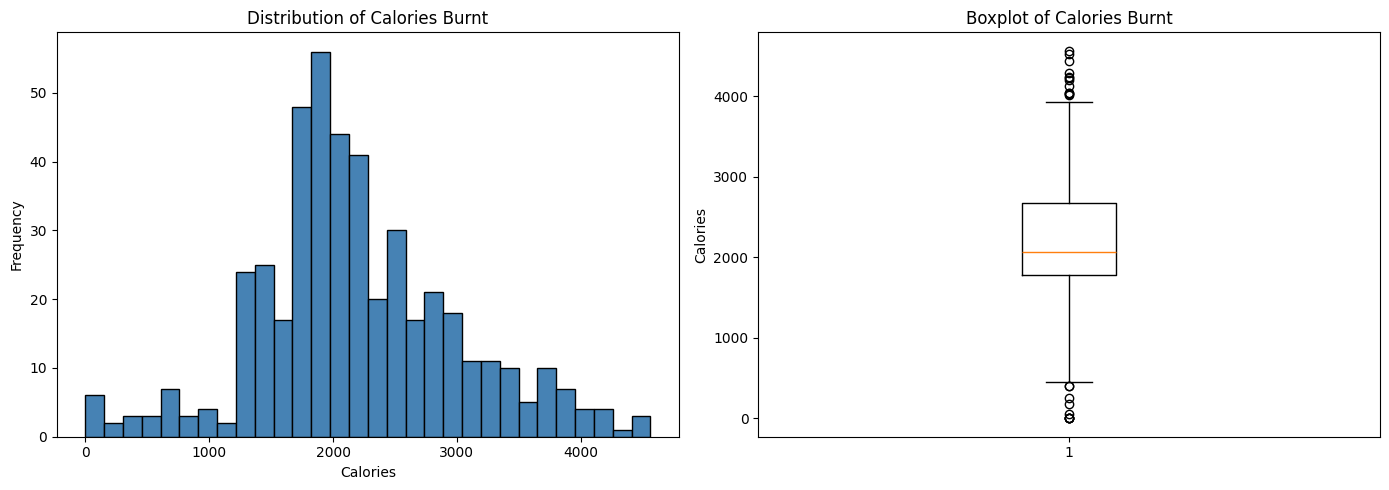

Calories Statistics:
count     457.000000
mean     2189.452954
std       815.484523
min         0.000000
25%      1776.000000
50%      2062.000000
75%      2667.000000
max      4562.000000
Name: Calories, dtype: float64


In [10]:
# Distribution of Calories
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['Calories'], bins=30, color='steelblue', edgecolor='black')
axes[0].set_title('Distribution of Calories Burnt')
axes[0].set_xlabel('Calories')
axes[0].set_ylabel('Frequency')

axes[1].boxplot(df['Calories'], vert=True)
axes[1].set_title('Boxplot of Calories Burnt')
axes[1].set_ylabel('Calories')

plt.tight_layout()
plt.show()

print("Calories Statistics:")
print(df['Calories'].describe())


### 4.3 Distribution of Key Numerical Features


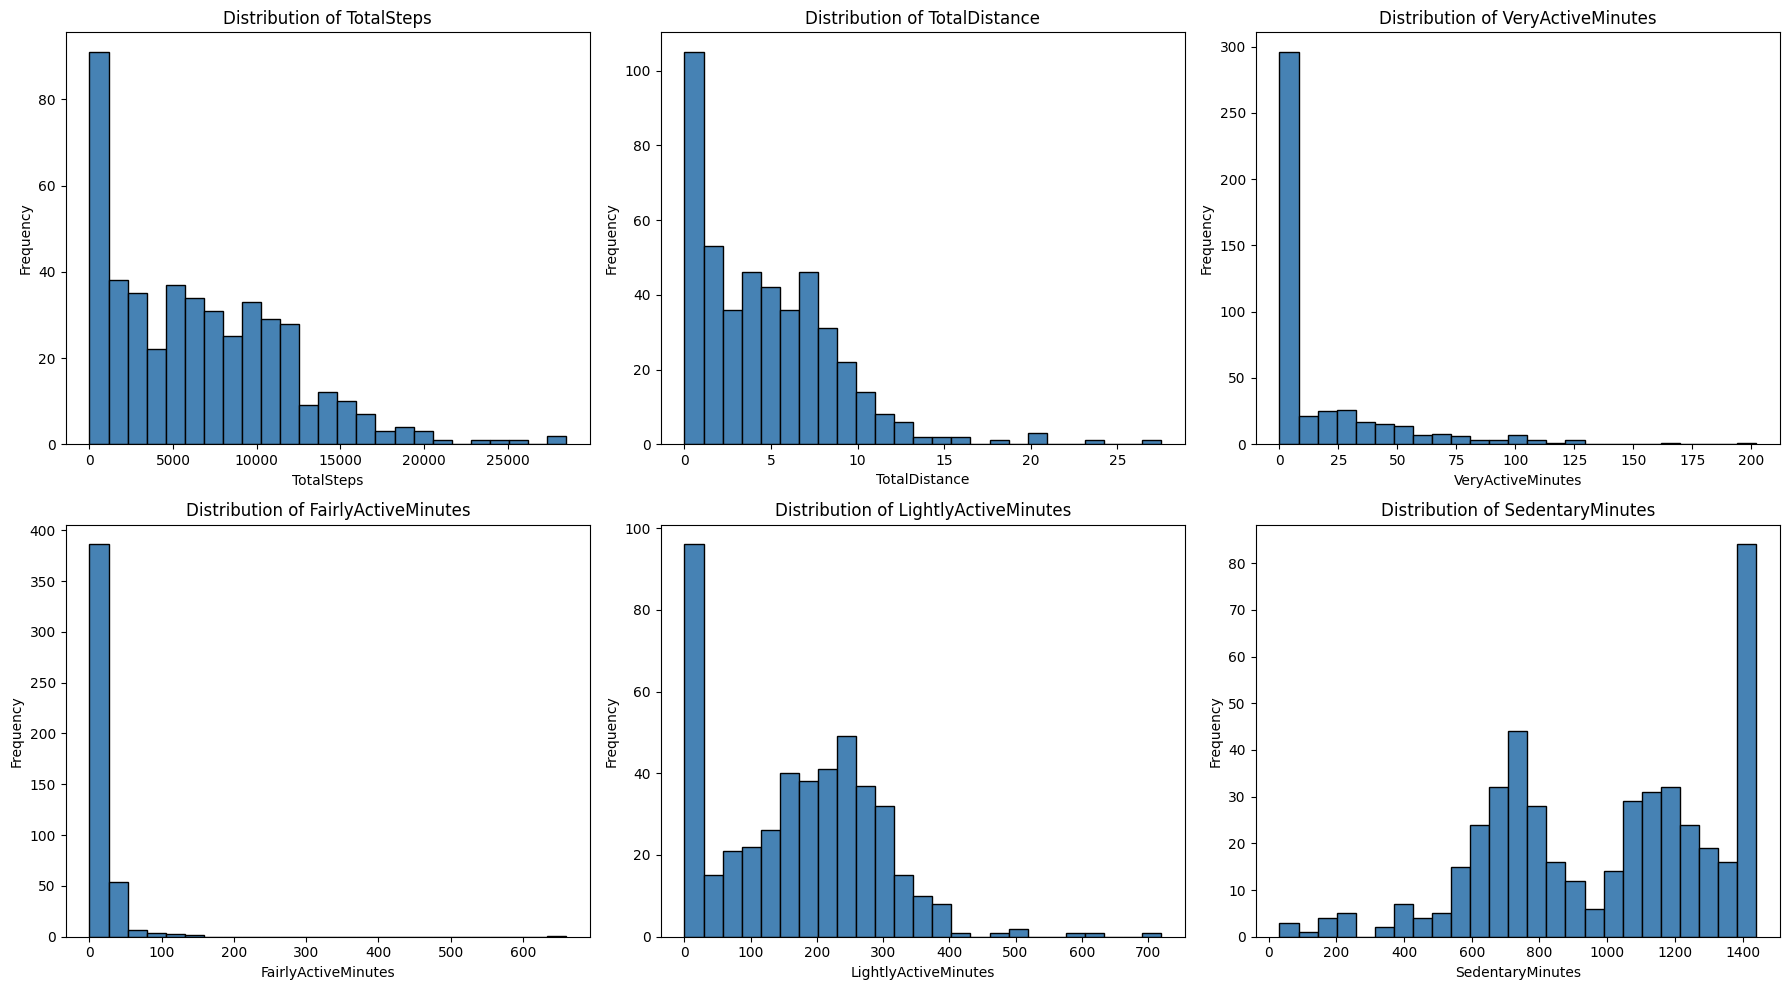

In [11]:
# Distribution of key activity features
activity_cols = ['TotalSteps', 'TotalDistance', 'VeryActiveMinutes',
                 'FairlyActiveMinutes', 'LightlyActiveMinutes', 'SedentaryMinutes']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(activity_cols):
    axes[i].hist(df[col], bins=25, color='steelblue', edgecolor='black')
    axes[i].set_title(f'Distribution of {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency')

plt.tight_layout()
plt.show()


### 4.4 Correlation Analysis


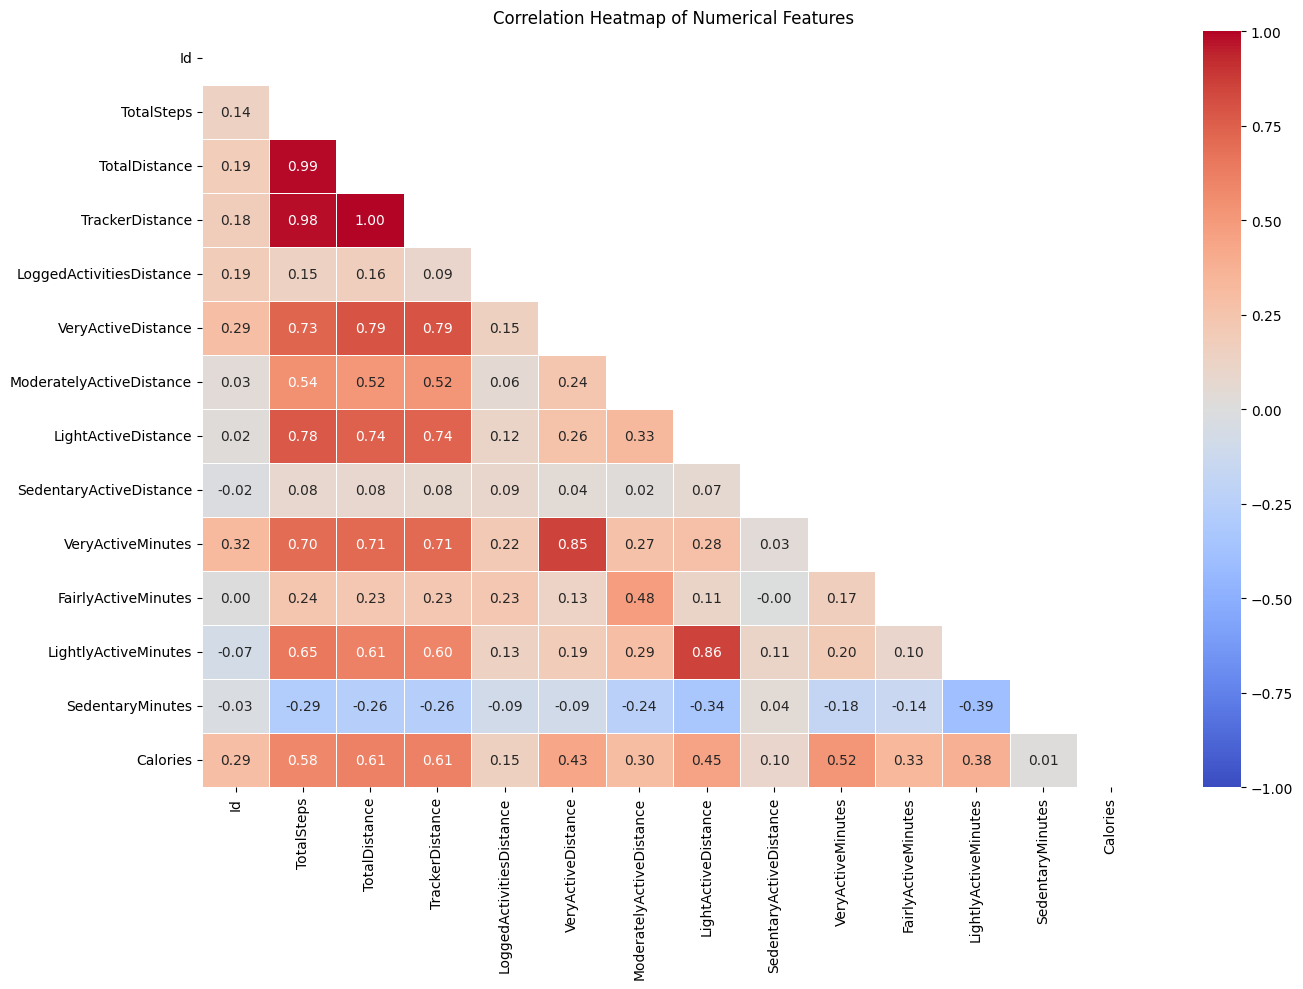

In [12]:
# Correlation heatmap for all numerical features
numeric_df = df.select_dtypes(include=[np.number])

plt.figure(figsize=(14, 10))
corr_matrix = numeric_df.corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, vmin=-1, vmax=1)
plt.title('Correlation Heatmap of Numerical Features')
plt.tight_layout()
plt.show()


In [13]:
# Correlation of each feature with the target variable Calories
calorie_corr = numeric_df.corr()['Calories'].drop('Calories').sort_values(ascending=False)
print("Correlation of features with Calories (Target):")
print(calorie_corr)


Correlation of features with Calories (Target):
TotalDistance               0.613647
TrackerDistance             0.612066
TotalSteps                  0.581380
VeryActiveMinutes           0.518905
LightActiveDistance         0.451239
VeryActiveDistance          0.434133
LightlyActiveMinutes        0.377249
FairlyActiveMinutes         0.334550
ModeratelyActiveDistance    0.300781
Id                          0.290868
LoggedActivitiesDistance    0.148740
SedentaryActiveDistance     0.096874
SedentaryMinutes            0.011824
Name: Calories, dtype: float64


### 4.5 Scatter Plots: Activity Minutes vs Calories

These plots help us understand the relationship between individual activity indicators and calorie expenditure.


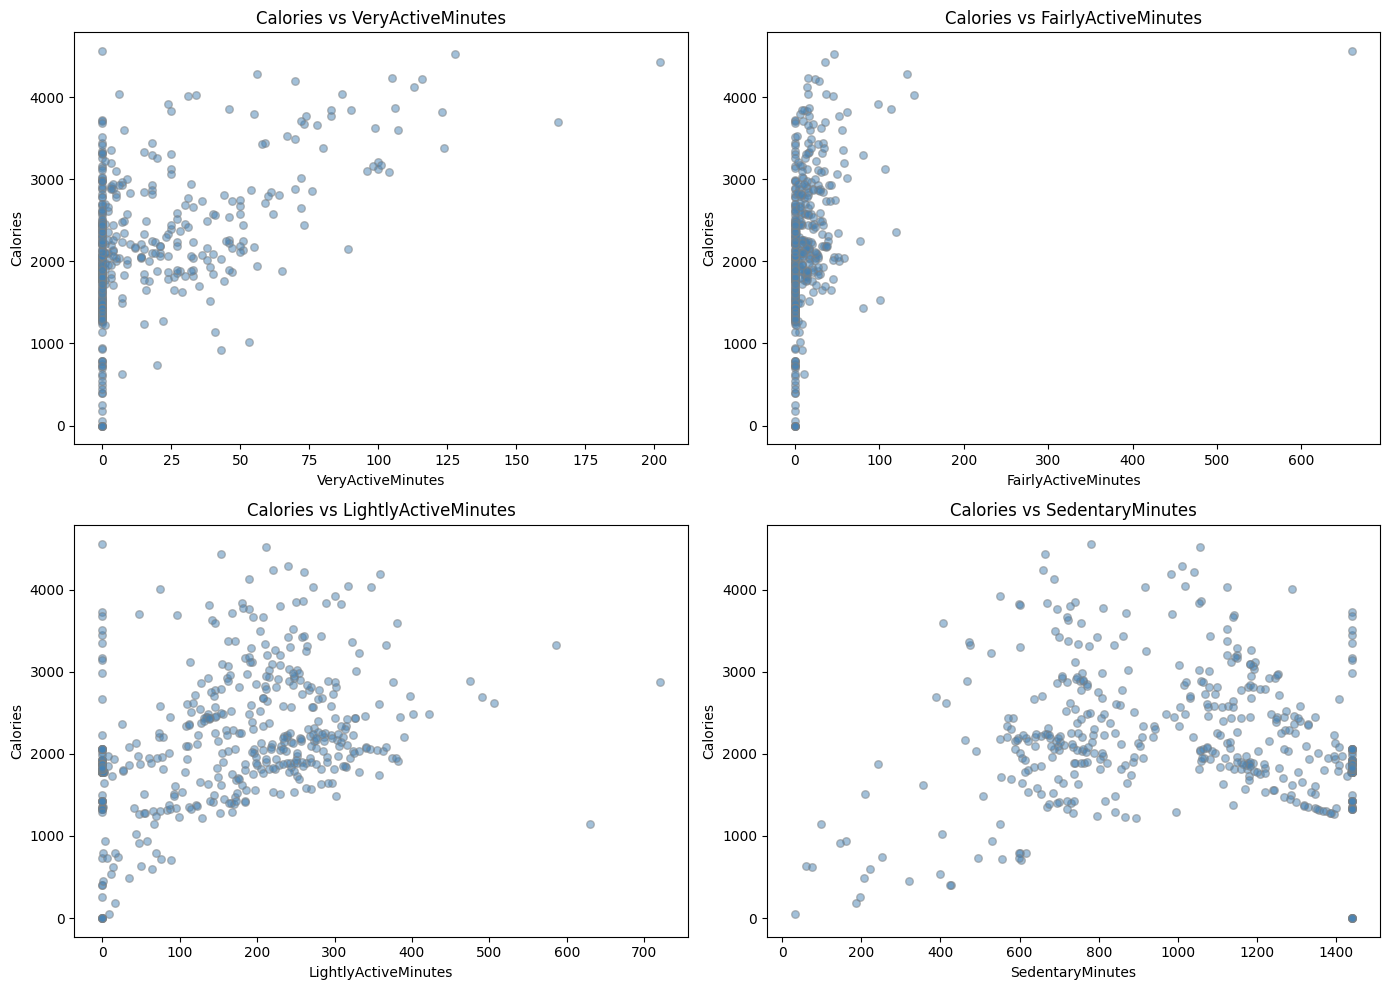

In [14]:
# Scatter plots of activity minutes vs Calories
minute_cols = ['VeryActiveMinutes', 'FairlyActiveMinutes', 'LightlyActiveMinutes', 'SedentaryMinutes']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, col in enumerate(minute_cols):
    axes[i].scatter(df[col], df['Calories'], alpha=0.5, color='steelblue', edgecolor='grey', s=30)
    axes[i].set_title(f'Calories vs {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Calories')

plt.tight_layout()
plt.show()


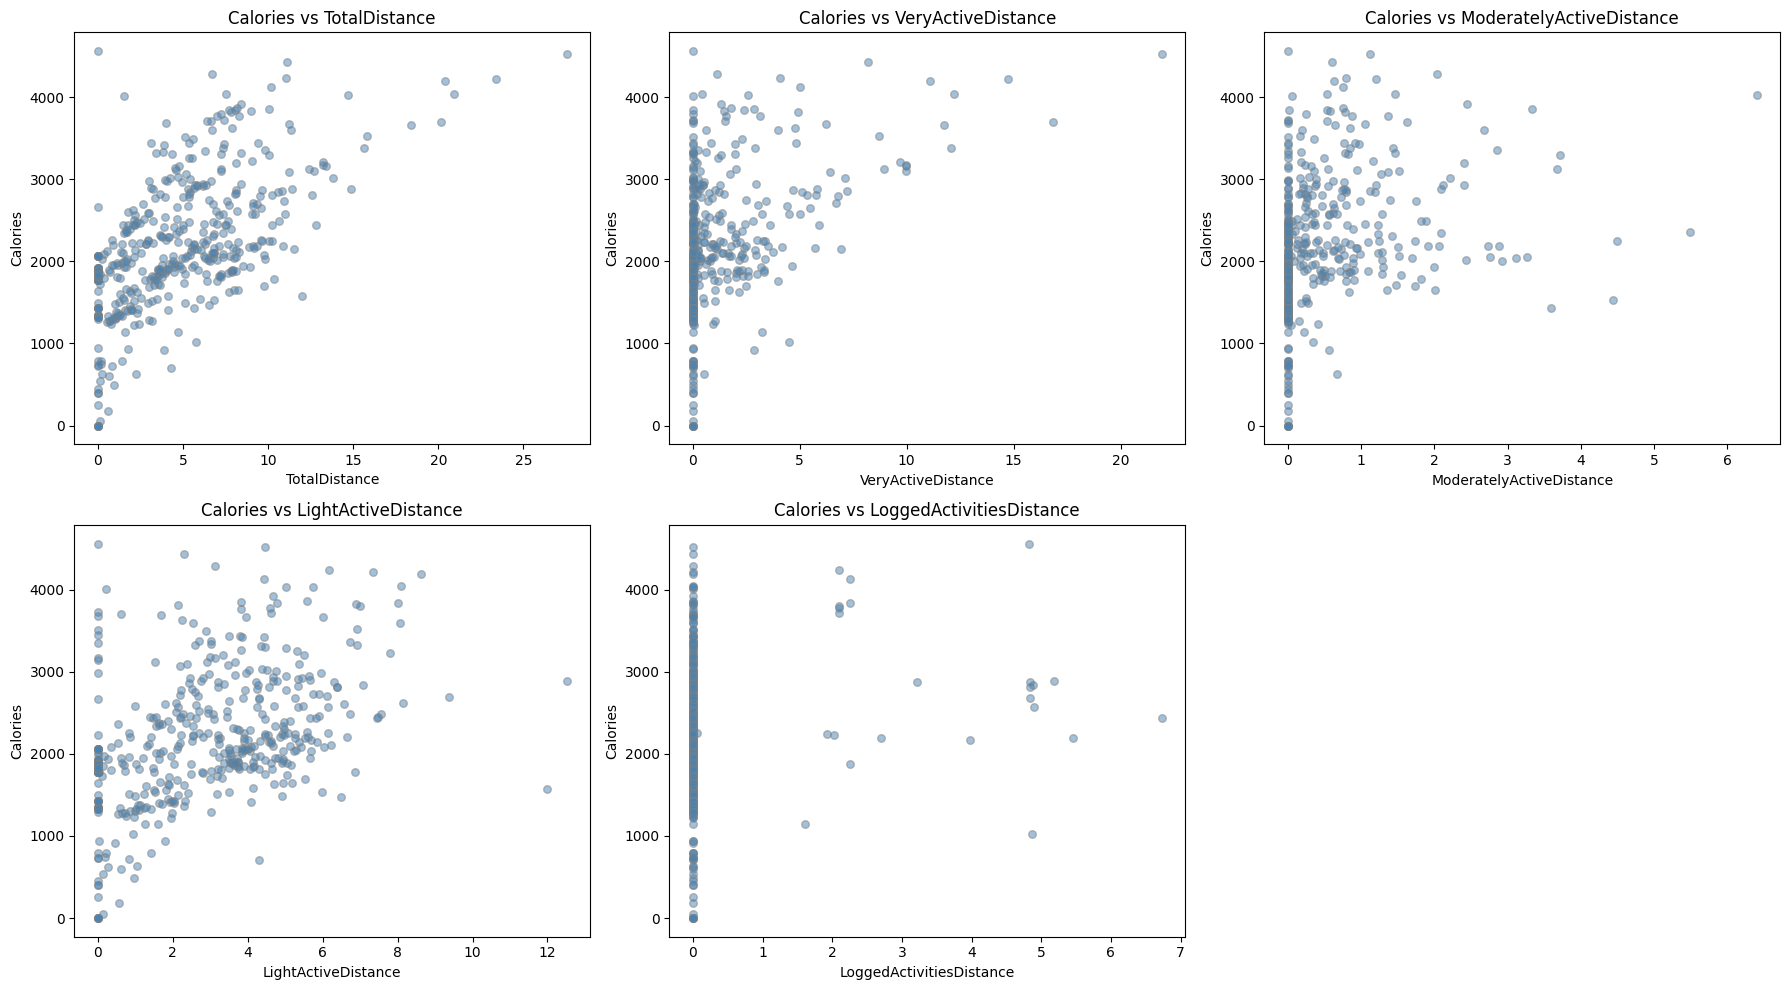

In [15]:
# Scatter plots of distance features vs Calories
distance_cols = ['TotalDistance', 'VeryActiveDistance', 'ModeratelyActiveDistance',
                 'LightActiveDistance', 'LoggedActivitiesDistance']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(distance_cols):
    axes[i].scatter(df[col], df['Calories'], alpha=0.5, color='steelblue', edgecolor='grey', s=30)
    axes[i].set_title(f'Calories vs {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Calories')

# Remove the empty subplot
axes[5].set_visible(False)

plt.tight_layout()
plt.show()


### 4.6 Scatter Plot: Total Steps vs Calories


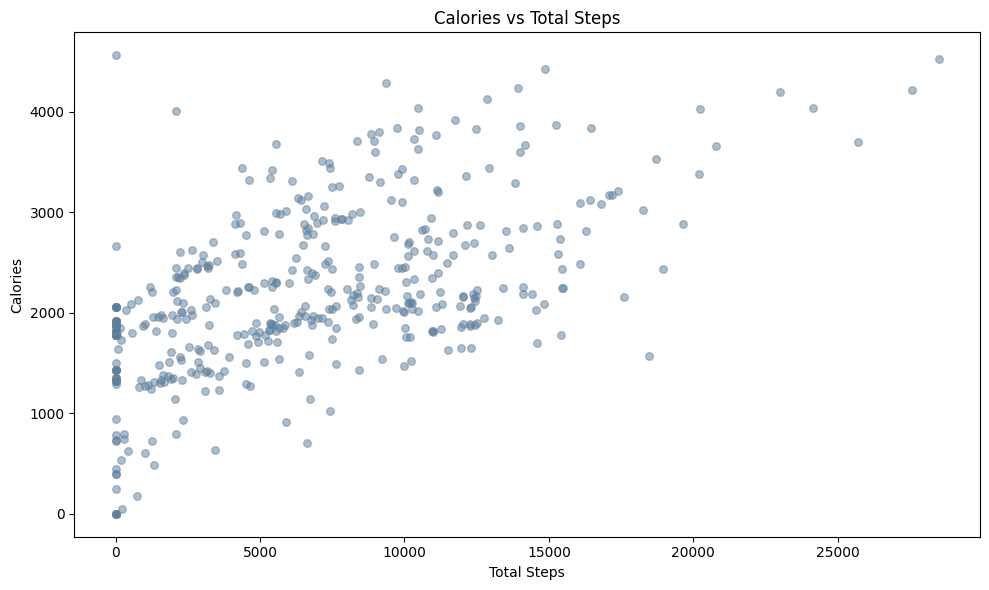

In [16]:
plt.figure(figsize=(10, 6))
plt.scatter(df['TotalSteps'], df['Calories'], alpha=0.5, color='steelblue', edgecolor='grey', s=30)
plt.title('Calories vs Total Steps')
plt.xlabel('Total Steps')
plt.ylabel('Calories')
plt.tight_layout()
plt.show()


### 4.7 Multi-feature Comparison: Activity Minutes


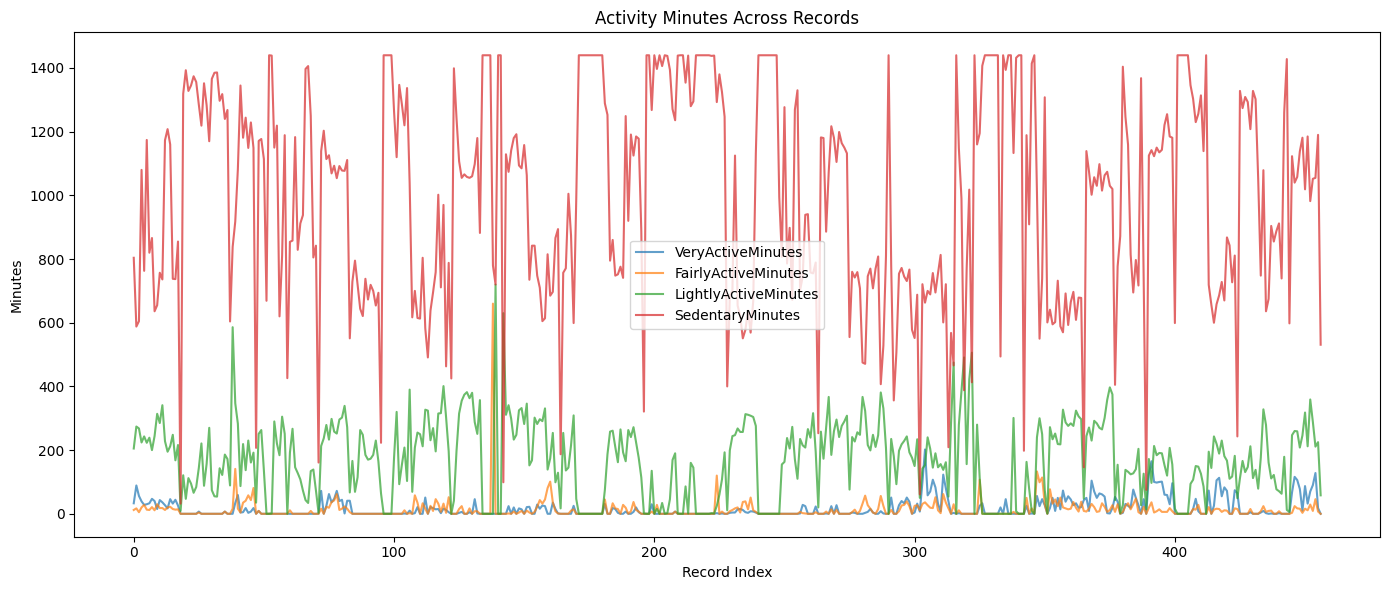

In [17]:
# Overlapping line plots of activity minutes across records
col_select = ['Calories', 'VeryActiveMinutes', 'FairlyActiveMinutes',
              'LightlyActiveMinutes', 'SedentaryMinutes']

fig, ax = plt.subplots(figsize=(14, 6))
for col in col_select[1:]:
    ax.plot(df[col].values, label=col, alpha=0.7)

ax.set_title('Activity Minutes Across Records')
ax.set_xlabel('Record Index')
ax.set_ylabel('Minutes')
ax.legend()
plt.tight_layout()
plt.show()


### 4.8 Multi-feature Comparison: Distance Features


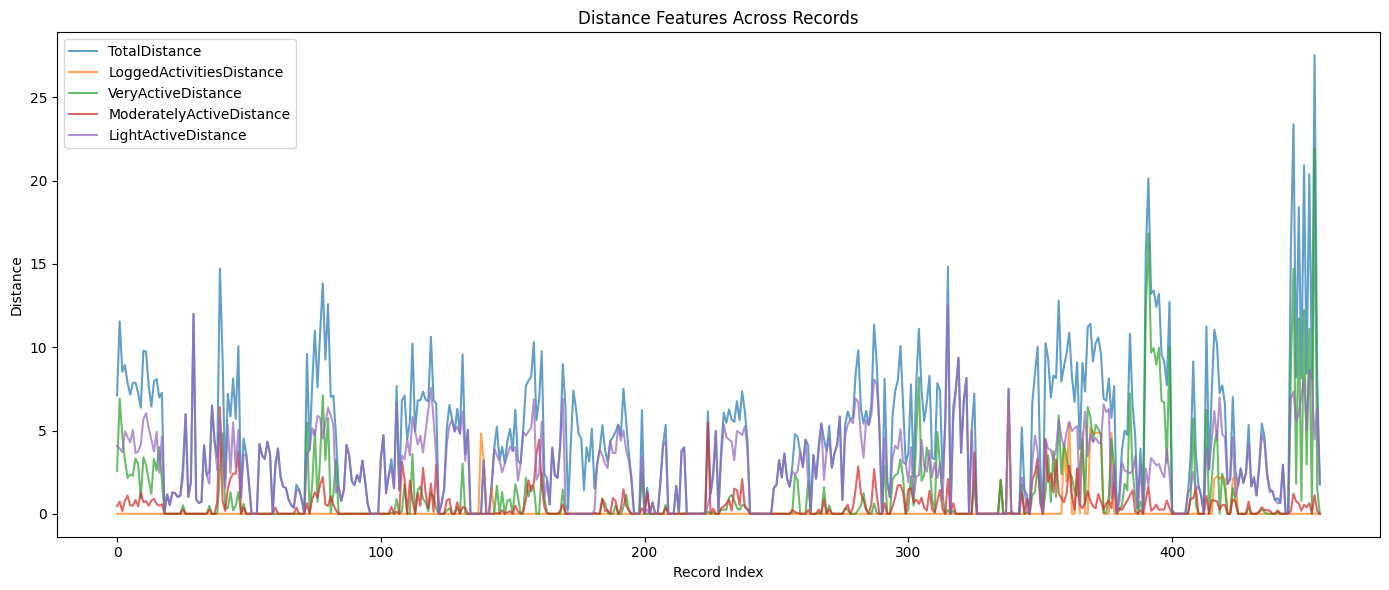

In [18]:
# Overlapping line plots of distance features across records
dist_select = ['TotalDistance', 'LoggedActivitiesDistance', 'VeryActiveDistance',
               'ModeratelyActiveDistance', 'LightActiveDistance']

fig, ax = plt.subplots(figsize=(14, 6))
for col in dist_select:
    ax.plot(df[col].values, label=col, alpha=0.7)

ax.set_title('Distance Features Across Records')
ax.set_xlabel('Record Index')
ax.set_ylabel('Distance')
ax.legend()
plt.tight_layout()
plt.show()


### 4.9 Pairplot of Selected Features


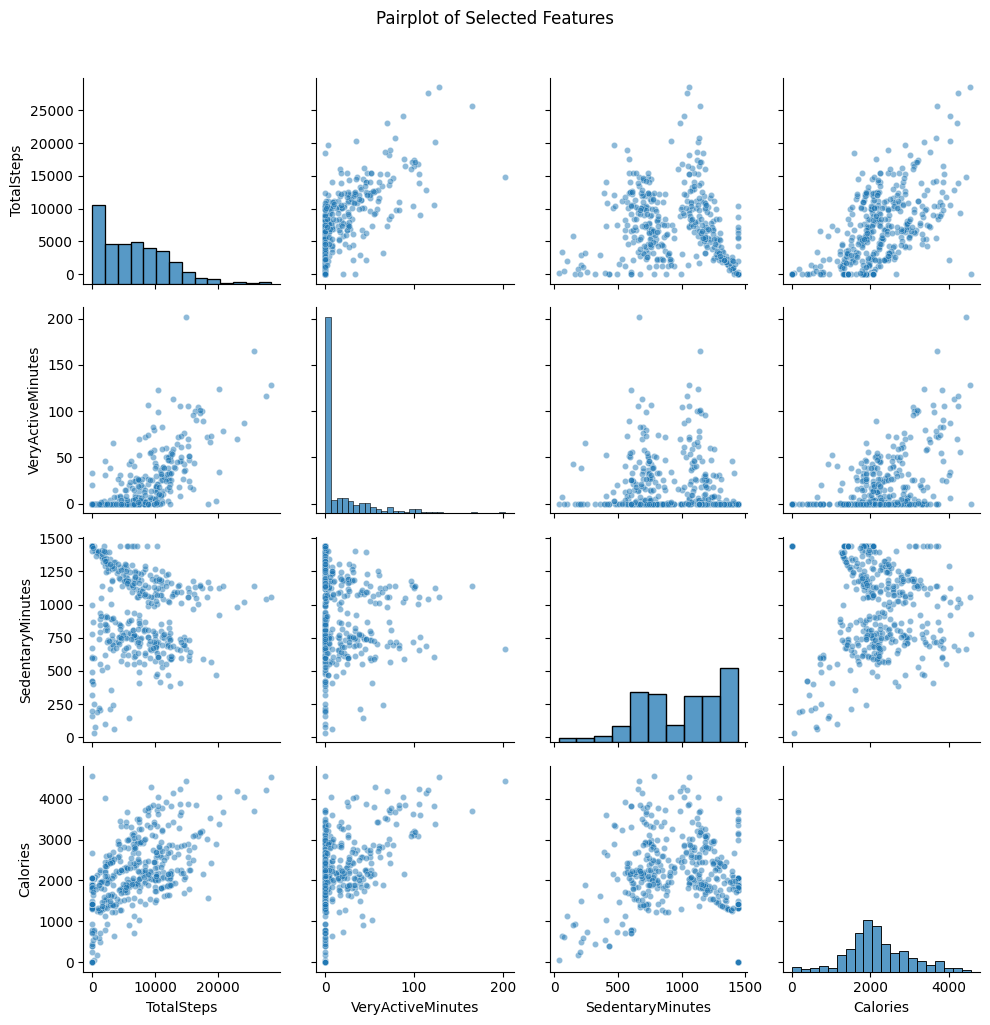

In [19]:
# Pairplot of selected features with target
selected_features = ['TotalSteps', 'VeryActiveMinutes', 'SedentaryMinutes', 'Calories']
sns.pairplot(df[selected_features], diag_kind='hist', plot_kws={'alpha': 0.5, 's': 20})
plt.suptitle('Pairplot of Selected Features', y=1.02)
plt.tight_layout()
plt.show()


### 4.10 Observations from EDA

Key findings from the exploratory analysis:

1. TotalDistance and TrackerDistance are highly correlated (nearly identical), indicating redundancy. TrackerDistance can be dropped.
2. VeryActiveMinutes and VeryActiveDistance show strong positive correlation with Calories, indicating high-intensity activity is a key predictor.
3. SedentaryMinutes shows a weak or slightly negative relationship with Calories.
4. LoggedActivitiesDistance has very low values for most records, suggesting limited manual activity logging by users.
5. TotalSteps has a moderate positive correlation with Calories.
6. The Id and ActivityDate columns are identifiers and not useful for model training.
7. No missing values are present in the raw dataset.


---
## 5. Data Preprocessing

This section handles data cleaning, feature selection, missing value imputation, and feature scaling, following the approach used in the project pipeline.


### 5.1 Drop Unnecessary Columns

Based on the EDA findings and the project architecture, we drop the following columns:
- Id: User identifier, not a predictive feature.
- ActivityDate: Date field, not directly useful for regression.
- TotalDistance: Highly correlated with TrackerDistance (redundant).
- TrackerDistance: Highly correlated with TotalDistance (redundant).


In [20]:
# Create a working copy of the dataset
data = df.copy()
print("Original shape:", data.shape)

# Drop unnecessary columns as identified in EDA and the project pipeline
columns_to_drop = ['Id', 'ActivityDate', 'TotalDistance', 'TrackerDistance']
data = data.drop(columns=columns_to_drop)
print("Shape after dropping unnecessary columns:", data.shape)
print()
print("Remaining columns:")
for col in data.columns:
    print(f"  - {col}")


Original shape: (457, 15)
Shape after dropping unnecessary columns: (457, 11)

Remaining columns:
  - TotalSteps
  - LoggedActivitiesDistance
  - VeryActiveDistance
  - ModeratelyActiveDistance
  - LightActiveDistance
  - SedentaryActiveDistance
  - VeryActiveMinutes
  - FairlyActiveMinutes
  - LightlyActiveMinutes
  - SedentaryMinutes
  - Calories


### 5.2 Replace Invalid Values with NaN

The project pipeline replaces string 'na' values with numpy NaN to enable proper imputation.


In [21]:
# Replace any 'na' string values with NaN
for column in data.columns:
    count = data[column][data[column] == 'na'].count()
    if count != 0:
        data[column] = data[column].replace('na', np.nan)
        print(f"Replaced {count} 'na' values in column: {column}")

# Ensure all columns are numeric
for col in data.columns:
    data[col] = pd.to_numeric(data[col], errors='coerce')

print("Data type conversion complete.")
print()
print(data.dtypes)


Data type conversion complete.

TotalSteps                    int64
LoggedActivitiesDistance    float64
VeryActiveDistance          float64
ModeratelyActiveDistance    float64
LightActiveDistance         float64
SedentaryActiveDistance     float64
VeryActiveMinutes             int64
FairlyActiveMinutes           int64
LightlyActiveMinutes          int64
SedentaryMinutes              int64
Calories                      int64
dtype: object


### 5.3 Check and Handle Missing Values


In [22]:
# Check for missing values after conversion
null_present = False
cols_with_missing = []

null_counts = data.isnull().sum()
for i, count in enumerate(null_counts):
    if count > 0:
        null_present = True
        cols_with_missing.append(data.columns[i])

if null_present:
    print("Missing values found in the following columns:")
    missing_info = pd.DataFrame({
        'Column': data.columns,
        'Missing Count': data.isnull().sum().values,
        'Missing Percentage': (data.isnull().sum().values / len(data) * 100).round(2)
    })
    print(missing_info[missing_info['Missing Count'] > 0])
else:
    print("No missing values found in the dataset.")


No missing values found in the dataset.


In [23]:
# If missing values are present, impute using KNN Imputer
if null_present:
    print("Applying KNN Imputer with n_neighbors=3...")
    imputer = KNNImputer(n_neighbors=3, weights='uniform', missing_values=np.nan)
    imputed_array = imputer.fit_transform(data)
    data = pd.DataFrame(data=imputed_array, columns=data.columns)
    print("Imputation complete.")
    print("Missing values after imputation:", data.isnull().sum().sum())
else:
    print("No imputation needed. Dataset is clean.")


No imputation needed. Dataset is clean.


### 5.4 Check for Columns with Zero Standard Deviation


In [24]:
# Identify columns with zero standard deviation (constant columns)
desc = data.describe()
cols_zero_std = []
for col in data.columns:
    if desc[col]['std'] == 0:
        cols_zero_std.append(col)

if len(cols_zero_std) > 0:
    print("Columns with zero standard deviation (to be dropped):")
    for col in cols_zero_std:
        print(f"  - {col}")
    data = data.drop(columns=cols_zero_std)
    print("Columns dropped.")
else:
    print("No columns with zero standard deviation found.")

print("Final preprocessed data shape:", data.shape)


No columns with zero standard deviation found.
Final preprocessed data shape: (457, 11)


### 5.5 Separate Features and Target Variable


In [25]:
# Separate features (X) and target (Y)
X = data.drop(columns=['Calories'])
Y = data['Calories']

print("Feature matrix shape:", X.shape)
print("Target vector shape:", Y.shape)
print()
print("Feature columns:")
for col in X.columns:
    print(f"  - {col}")


Feature matrix shape: (457, 10)
Target vector shape: (457,)

Feature columns:
  - TotalSteps
  - LoggedActivitiesDistance
  - VeryActiveDistance
  - ModeratelyActiveDistance
  - LightActiveDistance
  - SedentaryActiveDistance
  - VeryActiveMinutes
  - FairlyActiveMinutes
  - LightlyActiveMinutes
  - SedentaryMinutes


---
## 6. KMeans Clustering

The project uses a clustering-based approach to segment the data before model training. The rationale is that different clusters of activity patterns may benefit from different regression models. The optimum number of clusters is determined using the Elbow Method with the KneeLocator.


### 6.1 Elbow Plot to Determine Optimal Clusters


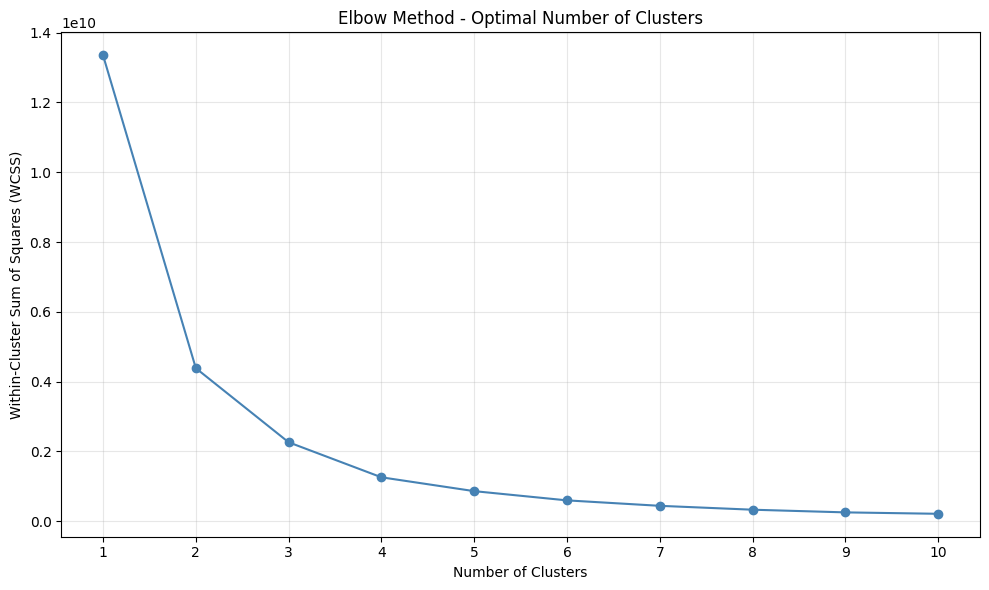

Optimal number of clusters determined by KneeLocator: 3


In [26]:
# Elbow method for finding the optimal number of clusters
wcss = []
K_range = range(1, 11)

for i in K_range:
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42, n_init=10)
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)

# Plot the elbow curve
plt.figure(figsize=(10, 6))
plt.plot(K_range, wcss, marker='o', linestyle='-', color='steelblue')
plt.title('Elbow Method - Optimal Number of Clusters')
plt.xlabel('Number of Clusters')
plt.ylabel('Within-Cluster Sum of Squares (WCSS)')
plt.xticks(K_range)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Use KneeLocator to find the optimal number of clusters programmatically
kn = KneeLocator(range(1, 11), wcss, curve='convex', direction='decreasing')
optimal_clusters = kn.knee
print(f"Optimal number of clusters determined by KneeLocator: {optimal_clusters}")


### 6.2 Create Clusters


In [27]:
# Fit KMeans with the optimal number of clusters
kmeans_model = KMeans(n_clusters=optimal_clusters, init='k-means++', random_state=42, n_init=10)
y_kmeans = kmeans_model.fit_predict(X)

# Add cluster labels to the feature matrix
X_clustered = X.copy()
X_clustered['Cluster'] = y_kmeans

print("Cluster distribution:")
print(X_clustered['Cluster'].value_counts().sort_index())


Cluster distribution:
Cluster
0    192
1     80
2    185
Name: count, dtype: int64


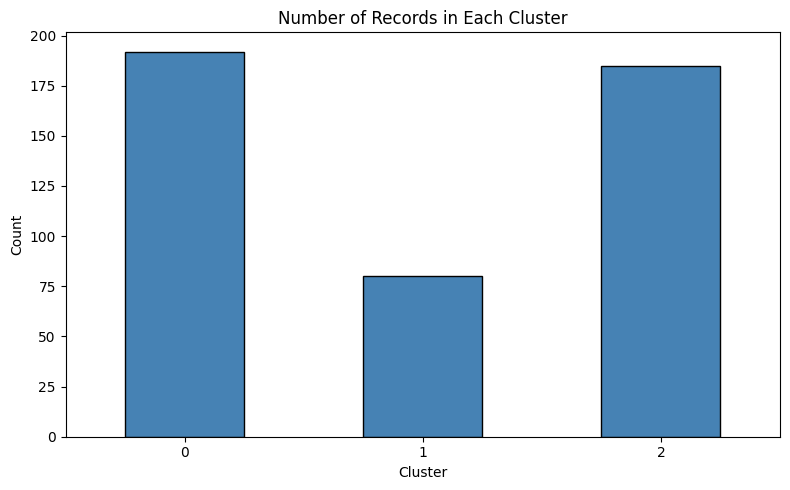

In [28]:
# Visualize cluster sizes
plt.figure(figsize=(8, 5))
X_clustered['Cluster'].value_counts().sort_index().plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('Number of Records in Each Cluster')
plt.xlabel('Cluster')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


---
## 7. Model Training

For each cluster, the pipeline trains two regression models:
1. Decision Tree Regressor - with hyperparameter tuning via GridSearchCV.
2. XGBoost Regressor - with hyperparameter tuning via GridSearchCV.

The model with the higher R-squared score on the test set is selected as the best model for that cluster.


### 7.1 Model Training Per Cluster


In [29]:
# Add the target variable back to the clustered dataframe
X_clustered['Labels'] = Y.values

# Get the list of unique clusters
list_of_clusters = X_clustered['Cluster'].unique()
list_of_clusters.sort()

print(f"Number of clusters: {len(list_of_clusters)}")
print(f"Clusters: {list_of_clusters}")


Number of clusters: 3
Clusters: [0 1 2]


In [30]:
# Dictionary to store results
cluster_results = {}
best_models = {}

for cluster_num in list_of_clusters:
    print("=" * 70)
    print(f"CLUSTER {cluster_num}")
    print("=" * 70)

    # Filter data for this cluster
    cluster_data = X_clustered[X_clustered['Cluster'] == cluster_num]
    print(f"Number of records in cluster {cluster_num}: {len(cluster_data)}")

    # Separate features and labels
    cluster_features = cluster_data.drop(columns=['Labels', 'Cluster'])
    cluster_label = cluster_data['Labels']

    # Train-test split
    x_train, x_test, y_train, y_test = train_test_split(
        cluster_features, cluster_label, test_size=1/3, random_state=36
    )
    print(f"Training samples: {len(x_train)}, Test samples: {len(x_test)}")

    # Standard scaling
    scaler = StandardScaler()
    x_train_scaled = scaler.fit_transform(x_train)
    x_test_scaled = scaler.transform(x_test)

    # ---- Decision Tree Regressor with GridSearchCV ----
    print()
    print(f"  Training Decision Tree Regressor for Cluster {cluster_num}...")

    dt_param_grid = {
        "criterion": ["squared_error", "friedman_mse", "absolute_error"],
        "splitter": ["best", "random"],
        "max_features": ["sqrt", "log2"],
        "max_depth": range(2, 16, 2),
        "min_samples_split": range(2, 16, 2)
    }

    dt_grid = GridSearchCV(
        DecisionTreeRegressor(), dt_param_grid, cv=5, scoring='r2', n_jobs=-1
    )
    dt_grid.fit(x_train_scaled, y_train)

    dt_best = dt_grid.best_estimator_
    dt_pred = dt_best.predict(x_test_scaled)
    dt_r2 = r2_score(y_test, dt_pred)
    dt_mae = mean_absolute_error(y_test, dt_pred)
    dt_rmse = np.sqrt(mean_squared_error(y_test, dt_pred))

    print(f"  Decision Tree - Best Params: {dt_grid.best_params_}")
    print(f"  Decision Tree - R2 Score: {dt_r2:.4f}, MAE: {dt_mae:.2f}, RMSE: {dt_rmse:.2f}")

    # ---- XGBoost Regressor with GridSearchCV ----
    print()
    print(f"  Training XGBoost Regressor for Cluster {cluster_num}...")

    xgb_param_grid = {
        "learning_rate": [0.5, 0.1, 0.01, 0.001],
        "max_depth": [3, 5, 10, 20],
        "n_estimators": [10, 50, 100, 200]
    }

    xgb_grid = GridSearchCV(
        XGBRegressor(objective='reg:squarederror', verbosity=0),
        xgb_param_grid, cv=5, scoring='r2', n_jobs=-1
    )
    xgb_grid.fit(x_train_scaled, y_train)

    xgb_best = xgb_grid.best_estimator_
    xgb_pred = xgb_best.predict(x_test_scaled)
    xgb_r2 = r2_score(y_test, xgb_pred)
    xgb_mae = mean_absolute_error(y_test, xgb_pred)
    xgb_rmse = np.sqrt(mean_squared_error(y_test, xgb_pred))

    print(f"  XGBoost - Best Params: {xgb_grid.best_params_}")
    print(f"  XGBoost - R2 Score: {xgb_r2:.4f}, MAE: {xgb_mae:.2f}, RMSE: {xgb_rmse:.2f}")

    # ---- Select the best model ----
    if xgb_r2 > dt_r2:
        best_model_name = 'XGBoost'
        best_model = xgb_best
        best_r2 = xgb_r2
        best_mae = xgb_mae
        best_rmse = xgb_rmse
    else:
        best_model_name = 'DecisionTreeRegressor'
        best_model = dt_best
        best_r2 = dt_r2
        best_mae = dt_mae
        best_rmse = dt_rmse

    print()
    print(f"  >>> Best Model for Cluster {cluster_num}: {best_model_name} (R2: {best_r2:.4f})")

    # Store results
    cluster_results[cluster_num] = {
        'Best Model': best_model_name,
        'R2 Score': round(best_r2, 4),
        'MAE': round(best_mae, 2),
        'RMSE': round(best_rmse, 2),
        'DT R2': round(dt_r2, 4),
        'XGB R2': round(xgb_r2, 4),
        'Records': len(cluster_data)
    }
    best_models[cluster_num] = {
        'model_name': best_model_name,
        'model': best_model,
        'scaler': scaler,
        'predictions': xgb_pred if best_model_name == 'XGBoost' else dt_pred,
        'y_test': y_test
    }
    print()


CLUSTER 0
Number of records in cluster 0: 192
Training samples: 128, Test samples: 64



  Training Decision Tree Regressor for Cluster 0...


  Decision Tree - Best Params: {'criterion': 'friedman_mse', 'max_depth': 10, 'max_features': 'log2', 'min_samples_split': 14, 'splitter': 'best'}
  Decision Tree - R2 Score: 0.2417, MAE: 463.10, RMSE: 648.96

  Training XGBoost Regressor for Cluster 0...


  XGBoost - Best Params: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 200}
  XGBoost - R2 Score: 0.2293, MAE: 451.57, RMSE: 654.24

  >>> Best Model for Cluster 0: DecisionTreeRegressor (R2: 0.2417)

CLUSTER 1
Number of records in cluster 1: 80
Training samples: 53, Test samples: 27

  Training Decision Tree Regressor for Cluster 1...


  Decision Tree - Best Params: {'criterion': 'squared_error', 'max_depth': 14, 'max_features': 'log2', 'min_samples_split': 8, 'splitter': 'random'}
  Decision Tree - R2 Score: 0.2801, MAE: 471.39, RMSE: 694.28

  Training XGBoost Regressor for Cluster 1...


  XGBoost - Best Params: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 200}
  XGBoost - R2 Score: 0.3591, MAE: 500.75, RMSE: 655.09

  >>> Best Model for Cluster 1: XGBoost (R2: 0.3591)

CLUSTER 2
Number of records in cluster 2: 185
Training samples: 123, Test samples: 62

  Training Decision Tree Regressor for Cluster 2...


  Decision Tree - Best Params: {'criterion': 'squared_error', 'max_depth': 6, 'max_features': 'log2', 'min_samples_split': 2, 'splitter': 'random'}
  Decision Tree - R2 Score: 0.0824, MAE: 460.96, RMSE: 653.92

  Training XGBoost Regressor for Cluster 2...


  XGBoost - Best Params: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100}
  XGBoost - R2 Score: 0.5162, MAE: 362.70, RMSE: 474.80

  >>> Best Model for Cluster 2: XGBoost (R2: 0.5162)



---
## 8. Model Evaluation and Results Summary


### 8.1 Cluster-wise Model Performance Summary


In [31]:
# Summary table of results
results_df = pd.DataFrame(cluster_results).T
results_df.index.name = 'Cluster'
print("Cluster-wise Model Selection Summary:")
print()
print(results_df.to_string())


Cluster-wise Model Selection Summary:

                    Best Model R2 Score     MAE    RMSE   DT R2  XGB R2 Records
Cluster                                                                        
0        DecisionTreeRegressor   0.2417   463.1  648.96  0.2417  0.2293     192
1                      XGBoost   0.3591  500.75  655.09  0.2801  0.3591      80
2                      XGBoost   0.5162   362.7   474.8  0.0824  0.5162     185


### 8.2 R2 Score Comparison Across Clusters


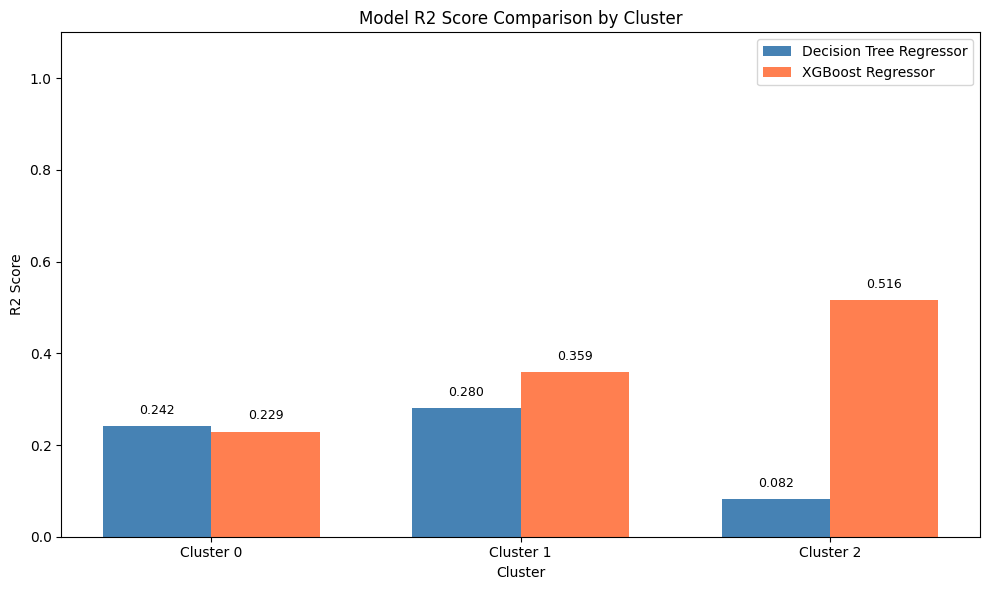

In [32]:
# Bar chart comparing Decision Tree vs XGBoost R2 scores per cluster
cluster_ids = sorted(list(cluster_results.keys()))
dt_scores = [cluster_results[c]['DT R2'] for c in cluster_ids]
xgb_scores = [cluster_results[c]['XGB R2'] for c in cluster_ids]

x_pos = np.arange(len(cluster_ids))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
bars1 = ax.bar(x_pos - width/2, dt_scores, width, label='Decision Tree Regressor', color='steelblue')
bars2 = ax.bar(x_pos + width/2, xgb_scores, width, label='XGBoost Regressor', color='coral')

ax.set_xlabel('Cluster')
ax.set_ylabel('R2 Score')
ax.set_title('Model R2 Score Comparison by Cluster')
ax.set_xticks(x_pos)
ax.set_xticklabels([f'Cluster {c}' for c in cluster_ids])
ax.legend()
ax.set_ylim(0, 1.1)

# Add value labels on bars
for bar in bars1:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 0.02, f'{height:.3f}',
            ha='center', va='bottom', fontsize=9)
for bar in bars2:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 0.02, f'{height:.3f}',
            ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()


### 8.3 Actual vs Predicted - Best Model Per Cluster


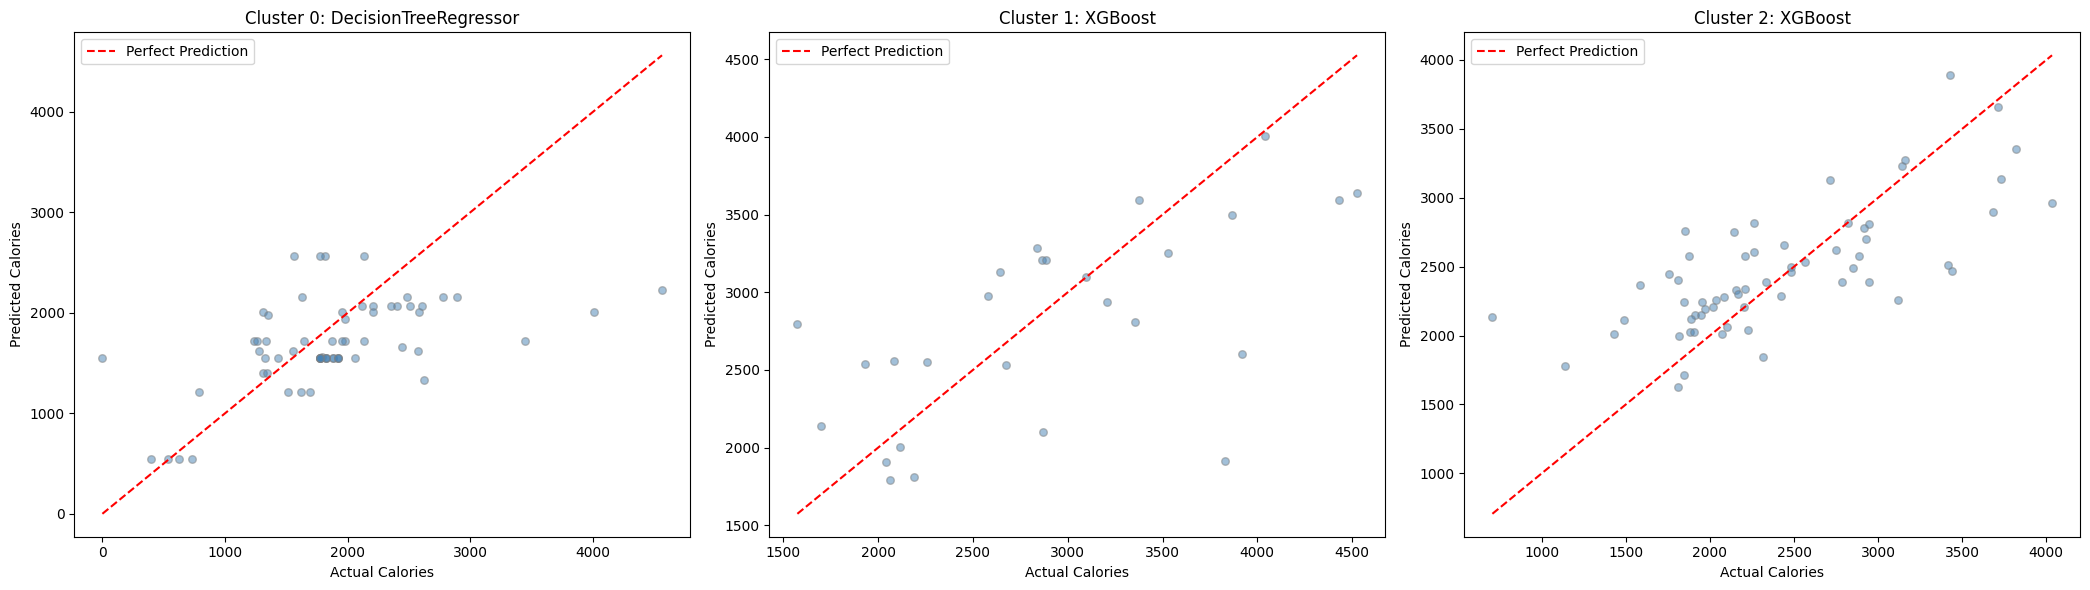

In [33]:
# Actual vs Predicted plots for each cluster
n_clusters = len(best_models)
fig, axes = plt.subplots(1, n_clusters, figsize=(7 * n_clusters, 6))

if n_clusters == 1:
    axes = [axes]

for idx, cluster_num in enumerate(sorted(best_models.keys())):
    model_info = best_models[cluster_num]
    y_actual = model_info['y_test']
    y_pred = model_info['predictions']
    model_name = model_info['model_name']

    ax = axes[idx]
    ax.scatter(y_actual, y_pred, alpha=0.5, color='steelblue', edgecolor='grey', s=30)

    # Plot the perfect prediction line
    min_val = min(y_actual.min(), y_pred.min())
    max_val = max(y_actual.max(), y_pred.max())
    ax.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=1.5, label='Perfect Prediction')

    ax.set_title(f'Cluster {cluster_num}: {model_name}')
    ax.set_xlabel('Actual Calories')
    ax.set_ylabel('Predicted Calories')
    ax.legend()

plt.tight_layout()
plt.show()


### 8.4 Residual Analysis - Best Model Per Cluster


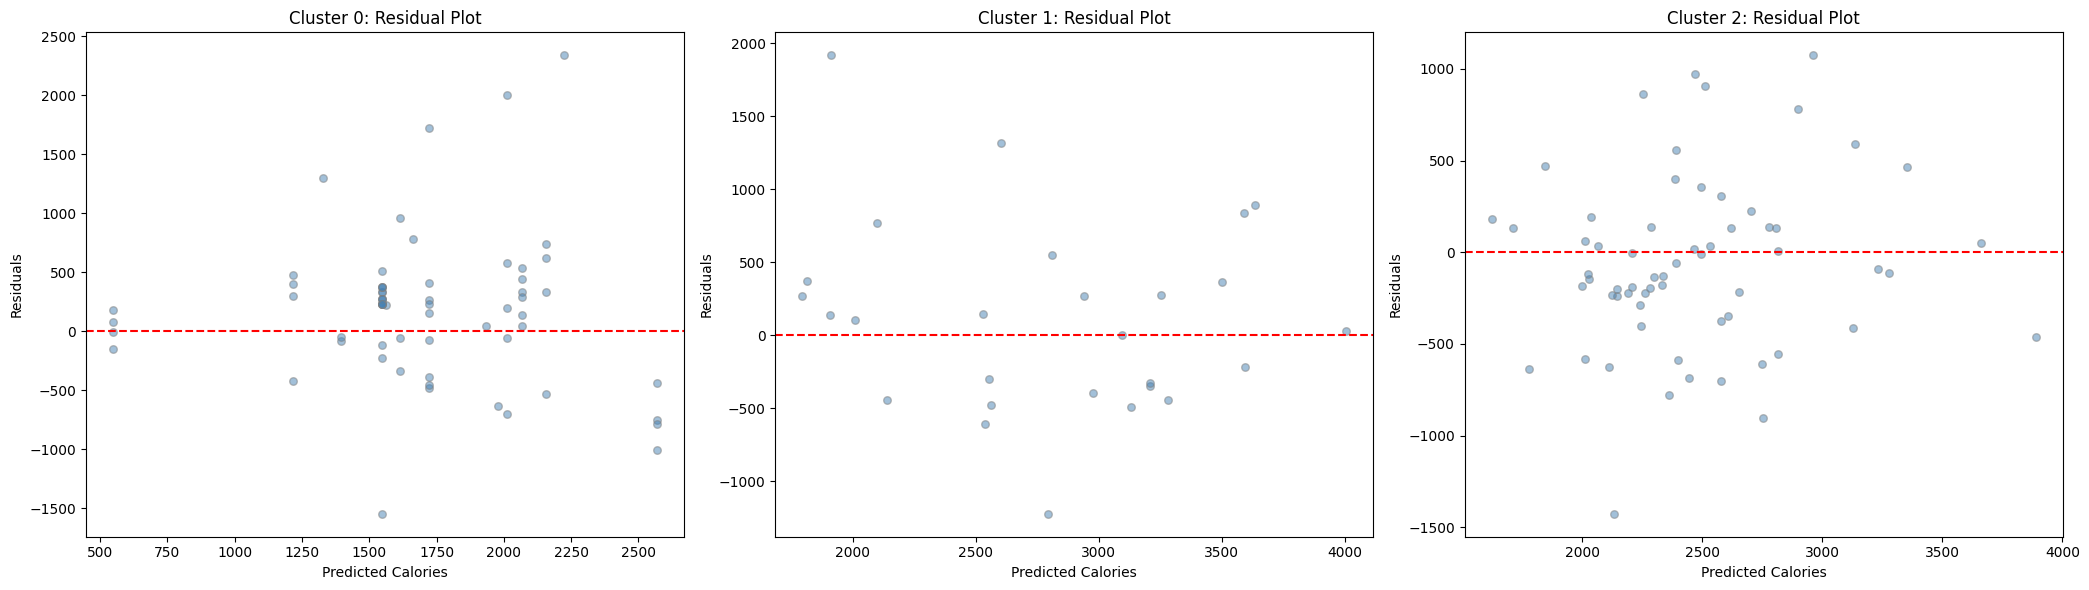

In [34]:
# Residual plots for each cluster
fig, axes = plt.subplots(1, n_clusters, figsize=(7 * n_clusters, 6))

if n_clusters == 1:
    axes = [axes]

for idx, cluster_num in enumerate(sorted(best_models.keys())):
    model_info = best_models[cluster_num]
    y_actual = model_info['y_test']
    y_pred = model_info['predictions']
    residuals = y_actual.values - y_pred

    ax = axes[idx]
    ax.scatter(y_pred, residuals, alpha=0.5, color='steelblue', edgecolor='grey', s=30)
    ax.axhline(y=0, color='red', linestyle='--', linewidth=1.5)
    ax.set_title(f'Cluster {cluster_num}: Residual Plot')
    ax.set_xlabel('Predicted Calories')
    ax.set_ylabel('Residuals')

plt.tight_layout()
plt.show()


---
## 9. Additional Model: Random Forest Regressor (Full Dataset)

As an additional baseline comparison, we train a Random Forest Regressor on the entire preprocessed dataset without clustering.


In [35]:
# Prepare the full dataset for training (without clustering)
X_full = data.drop(columns=['Calories'])
Y_full = data['Calories']

x_train_full, x_test_full, y_train_full, y_test_full = train_test_split(
    X_full, Y_full, test_size=0.25, random_state=42
)

# Scale the data
scaler_full = StandardScaler()
x_train_full_scaled = scaler_full.fit_transform(x_train_full)
x_test_full_scaled = scaler_full.transform(x_test_full)

print(f"Full dataset - Training samples: {len(x_train_full)}, Test samples: {len(x_test_full)}")


Full dataset - Training samples: 342, Test samples: 115


In [36]:
# Train Random Forest Regressor with GridSearchCV
rf_param_grid = {
    "n_estimators": [50, 100, 130],
    "max_depth": range(3, 11, 1),
    "random_state": [0, 50, 100]
}

rf_grid = GridSearchCV(
    RandomForestRegressor(), rf_param_grid, cv=5, scoring='r2', n_jobs=-1
)
rf_grid.fit(x_train_full_scaled, y_train_full)

print(f"Random Forest - Best Parameters: {rf_grid.best_params_}")
print(f"Random Forest - Best CV Score: {rf_grid.best_score_:.4f}")


Random Forest - Best Parameters: {'max_depth': 10, 'n_estimators': 100, 'random_state': 100}
Random Forest - Best CV Score: 0.5767


In [37]:
# Evaluate Random Forest on test set
rf_best = rf_grid.best_estimator_
rf_pred = rf_best.predict(x_test_full_scaled)

rf_r2 = r2_score(y_test_full, rf_pred)
rf_mae = mean_absolute_error(y_test_full, rf_pred)
rf_rmse = np.sqrt(mean_squared_error(y_test_full, rf_pred))

print(f"Random Forest Test Performance:")
print(f"  R2 Score: {rf_r2:.4f}")
print(f"  MAE:      {rf_mae:.2f}")
print(f"  RMSE:     {rf_rmse:.2f}")


Random Forest Test Performance:
  R2 Score: 0.6267
  MAE:      379.54
  RMSE:     483.66


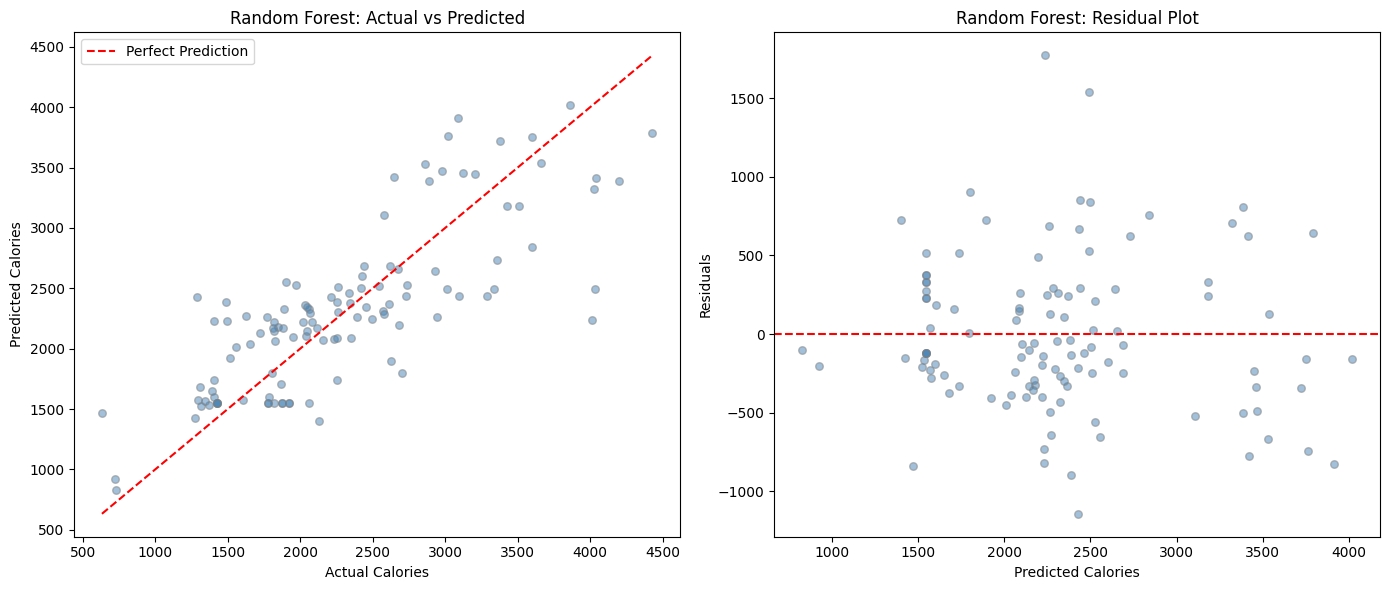

In [38]:
# Actual vs Predicted for Random Forest
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Scatter plot
axes[0].scatter(y_test_full, rf_pred, alpha=0.5, color='steelblue', edgecolor='grey', s=30)
min_val = min(y_test_full.min(), rf_pred.min())
max_val = max(y_test_full.max(), rf_pred.max())
axes[0].plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=1.5, label='Perfect Prediction')
axes[0].set_title('Random Forest: Actual vs Predicted')
axes[0].set_xlabel('Actual Calories')
axes[0].set_ylabel('Predicted Calories')
axes[0].legend()

# Residual plot
residuals_rf = y_test_full.values - rf_pred
axes[1].scatter(rf_pred, residuals_rf, alpha=0.5, color='steelblue', edgecolor='grey', s=30)
axes[1].axhline(y=0, color='red', linestyle='--', linewidth=1.5)
axes[1].set_title('Random Forest: Residual Plot')
axes[1].set_xlabel('Predicted Calories')
axes[1].set_ylabel('Residuals')

plt.tight_layout()
plt.show()


### 9.1 Feature Importance - Random Forest


Feature Importance Ranking:
                 Feature  Importance
              TotalSteps    0.357299
        SedentaryMinutes    0.195650
       VeryActiveMinutes    0.169708
     LightActiveDistance    0.082927
    LightlyActiveMinutes    0.075052
     FairlyActiveMinutes    0.061460
LoggedActivitiesDistance    0.018161
ModeratelyActiveDistance    0.017265
      VeryActiveDistance    0.015291
 SedentaryActiveDistance    0.007187


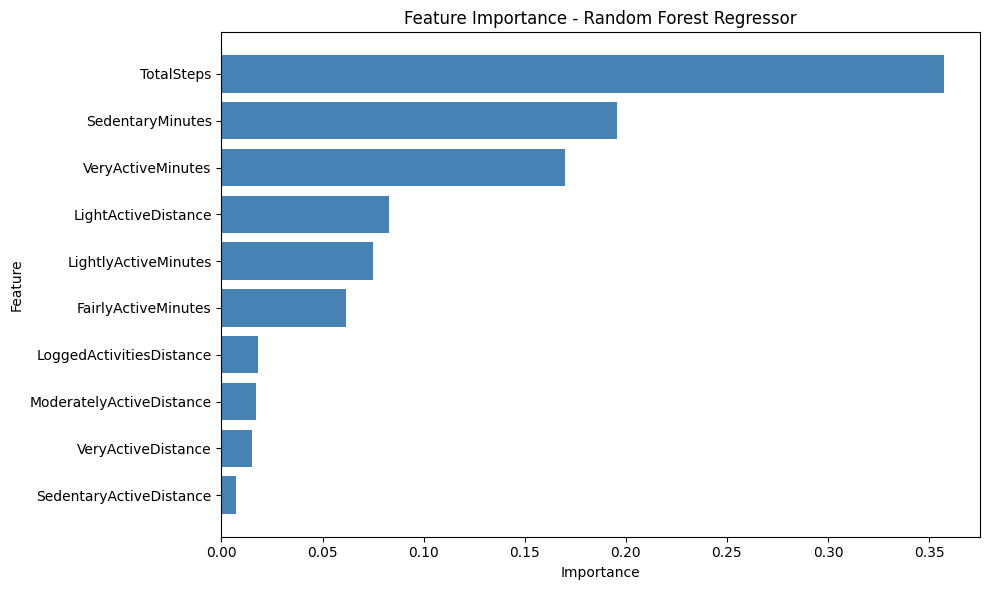

In [39]:
# Feature importance from the Random Forest model
feature_importance = pd.DataFrame({
    'Feature': X_full.columns,
    'Importance': rf_best.feature_importances_
}).sort_values(by='Importance', ascending=False)

print("Feature Importance Ranking:")
print(feature_importance.to_string(index=False))

plt.figure(figsize=(10, 6))
plt.barh(feature_importance['Feature'], feature_importance['Importance'], color='steelblue')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.title('Feature Importance - Random Forest Regressor')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


---
## 10. Additional Model: XGBoost Regressor (Full Dataset)


In [40]:
# Train XGBoost Regressor on full dataset with GridSearchCV
xgb_full_param_grid = {
    "n_estimators": [50, 100, 130],
    "max_depth": range(3, 11, 1),
    "learning_rate": [0.01, 0.1, 0.5]
}

xgb_full_grid = GridSearchCV(
    XGBRegressor(objective='reg:squarederror', verbosity=0),
    xgb_full_param_grid, cv=5, scoring='r2', n_jobs=-1
)
xgb_full_grid.fit(x_train_full_scaled, y_train_full)

print(f"XGBoost (Full Dataset) - Best Parameters: {xgb_full_grid.best_params_}")
print(f"XGBoost (Full Dataset) - Best CV Score: {xgb_full_grid.best_score_:.4f}")


XGBoost (Full Dataset) - Best Parameters: {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 130}
XGBoost (Full Dataset) - Best CV Score: 0.5770


In [41]:
# Evaluate XGBoost on full test set
xgb_full_best = xgb_full_grid.best_estimator_
xgb_full_pred = xgb_full_best.predict(x_test_full_scaled)

xgb_full_r2 = r2_score(y_test_full, xgb_full_pred)
xgb_full_mae = mean_absolute_error(y_test_full, xgb_full_pred)
xgb_full_rmse = np.sqrt(mean_squared_error(y_test_full, xgb_full_pred))

print(f"XGBoost (Full Dataset) Test Performance:")
print(f"  R2 Score: {xgb_full_r2:.4f}")
print(f"  MAE:      {xgb_full_mae:.2f}")
print(f"  RMSE:     {xgb_full_rmse:.2f}")


XGBoost (Full Dataset) Test Performance:
  R2 Score: 0.6338
  MAE:      373.52
  RMSE:     479.02


---
## 11. Final Model Comparison


In [42]:
# Compare all models
comparison_data = {
    'Model': ['Random Forest (Full)', 'XGBoost (Full)'],
    'R2 Score': [round(rf_r2, 4), round(xgb_full_r2, 4)],
    'MAE': [round(rf_mae, 2), round(xgb_full_mae, 2)],
    'RMSE': [round(rf_rmse, 2), round(xgb_full_rmse, 2)]
}

# Add cluster-based results
for cluster_num in sorted(cluster_results.keys()):
    result = cluster_results[cluster_num]
    comparison_data['Model'].append(f"{result['Best Model']} (Cluster {cluster_num})")
    comparison_data['R2 Score'].append(result['R2 Score'])
    comparison_data['MAE'].append(result['MAE'])
    comparison_data['RMSE'].append(result['RMSE'])

comparison_df = pd.DataFrame(comparison_data)
print("Final Model Comparison:")
print()
print(comparison_df.to_string(index=False))


Final Model Comparison:

                            Model  R2 Score    MAE   RMSE
             Random Forest (Full)    0.6267 379.54 483.66
                   XGBoost (Full)    0.6338 373.52 479.02
DecisionTreeRegressor (Cluster 0)    0.2417 463.10 648.96
              XGBoost (Cluster 1)    0.3591 500.75 655.09
              XGBoost (Cluster 2)    0.5162 362.70 474.80


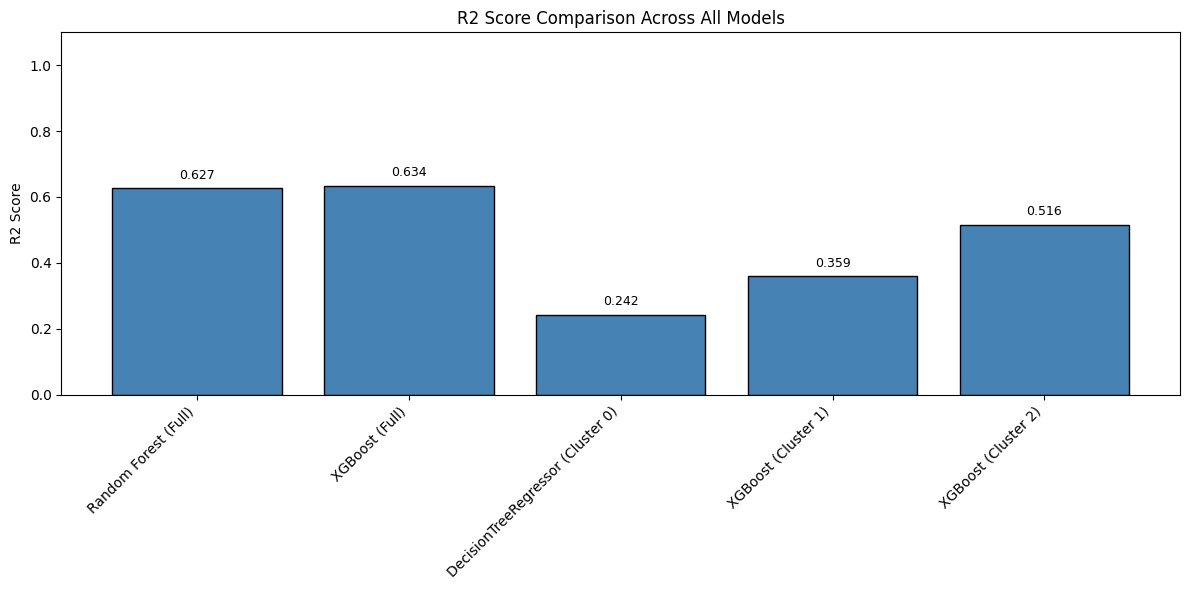

In [43]:
# Visualize final comparison
fig, ax = plt.subplots(figsize=(12, 6))
x_pos = np.arange(len(comparison_df))

bars = ax.bar(x_pos, comparison_df['R2 Score'], color='steelblue', edgecolor='black')
ax.set_xticks(x_pos)
ax.set_xticklabels(comparison_df['Model'], rotation=45, ha='right')
ax.set_ylabel('R2 Score')
ax.set_title('R2 Score Comparison Across All Models')
ax.set_ylim(0, 1.1)

for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 0.02, f'{height:.3f}',
            ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()


---
## 12. Conclusion

This notebook demonstrated a complete machine learning pipeline for predicting calorie expenditure from FitBit activity data:

1. The dataset contained 457 daily activity records with 15 features. After EDA, four columns (Id, ActivityDate, TotalDistance, TrackerDistance) were dropped due to being non-predictive or redundant.

2. The preprocessing pipeline handled missing value detection and imputation (KNN Imputer), invalid value replacement, and zero-variance column removal.

3. KMeans clustering was applied to segment the data into distinct activity pattern groups. The Elbow Method with KneeLocator determined the optimal number of clusters.

4. For each cluster, Decision Tree Regressor and XGBoost Regressor were trained with hyperparameter tuning via GridSearchCV. The model with the higher R2 score was selected for each cluster.

5. As additional baselines, Random Forest Regressor and XGBoost Regressor were trained on the full dataset without clustering.

6. The cluster-based approach allows the pipeline to tailor models to specific activity patterns, potentially improving prediction accuracy for diverse user groups.

The models and scalers can be saved and deployed for real-time calorie prediction in a production environment, as outlined in the project Flask-based deployment architecture.
